# Klasyfikacja EKG MIT-BIH: CWT + mała sieć konwolucyjna

Wejściem do klasyfikatora są obrazy 2D z ciągłej transformaty falkowej (CWT). Porównane są dwie falki:
`morl` i `mexh`. Podział walidacyjny pilnuje, aby pacjent/rekord z części testowej nie występował w treningu.

Sygnał jest analizowany w rozkładzie czasowo-falkowym: CWT daje macierz
`skala x czas`, czyli obraz, na którym uczona jest mała sieć konwolucyjna. 
Użyta jest lekka sieć konwolucyjna w NumPy/SciPy:
`Conv2D -> ReLU -> pooling -> warstwa klasyfikacyjna`. Bank filtrów konwolucyjnych działa jako ekstraktor
lokalnych wzorców czasowo-skalowych, a ostatnia warstwa jest uczona dla każdego foldu.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt

from IPython.display import Markdown, display
from scipy.signal import correlate2d, resample
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
DATA_DIR = ROOT / "MitBih" / "mitbih_database"
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Brak katalogu z danymi: {DATA_DIR}")

print(f"Katalog danych: {DATA_DIR}")
print(f"Liczba plików CSV: {len(list(DATA_DIR.glob('*.csv')))}")

Katalog danych: /home/ezdies/SignalBioAI/Lab7/MitBih/mitbih_database
Liczba plików CSV: 48


## Założenia przygotowania danych

MIT-BIH Arrhythmia Database ma sygnały próbkowane z częstotliwością 360 Hz. Segmenty są wycinane wokół
adnotowanych pobudzeń z kanału MLII, a etykieta binarna oznacza:

- `0`: pobudzenia normalne wg grupy AAMI (`N`, `L`, `R`, `e`, `j`)
- `1`: pozostałe pobudzenia rytmu serca, traktowane jako arytmia

Dla stabilnego i szybkiego przeliczenia notebook balansuje liczbę segmentów normalnych i arytmicznych
per pacjent/rekord. To ogranicza dominację klasy normalnej i spełnia założenie z notatek o balansowaniu.

In [2]:
FS = 360
WINDOW = 256
HALF_WINDOW = WINDOW // 2
NORMAL_SYMBOLS = {"N", "L", "R", "e", "j"}
EXCLUDED_SYMBOLS = {"+", "~", "|", "!", "[", "]", "x", "f", "Q", "?", '"'}
MAX_PER_CLASS_PER_RECORD = 18


def read_annotations(path: Path) -> pd.DataFrame:
    rows = []
    pattern = re.compile(r"^\s*(\S+)\s+(\d+)\s+(\S+)\s+")
    for line in path.read_text(errors="ignore").splitlines():
        match = pattern.match(line)
        if not match:
            continue
        _, sample, beat_type = match.groups()
        if beat_type in EXCLUDED_SYMBOLS:
            continue
        rows.append({"sample": int(sample), "type": beat_type})
    return pd.DataFrame(rows)


def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def load_segments(data_dir: Path) -> pd.DataFrame:
    records = []
    for csv_path in sorted(data_dir.glob("*.csv")):
        record_id = csv_path.stem
        ann_path = data_dir / f"{record_id}annotations.txt"
        if not ann_path.exists():
            continue

        signal_df = pd.read_csv(csv_path)
        signal_df.columns = [str(col).strip().strip("'\"") for col in signal_df.columns]
        channel = "MLII" if "MLII" in signal_df.columns else [col for col in signal_df.columns if col != "sample #"][0]
        signal = signal_df[channel].to_numpy(dtype=np.float32)
        annotations = read_annotations(ann_path)
        if annotations.empty:
            continue

        local = []
        for _, row in annotations.iterrows():
            center = int(row["sample"])
            start = center - HALF_WINDOW
            end = center + HALF_WINDOW
            if start < 0 or end > len(signal):
                continue
            label = 0 if row["type"] in NORMAL_SYMBOLS else 1
            local.append(
                {
                    "record": record_id,
                    "sample": center,
                    "symbol": row["type"],
                    "label": label,
                    "segment": zscore(signal[start:end]),
                }
            )

        if not local:
            continue
        local_df = pd.DataFrame(local)
        rng = np.random.default_rng(RANDOM_STATE + int(record_id))
        balanced_parts = []
        for label, group in local_df.groupby("label"):
            take = min(MAX_PER_CLASS_PER_RECORD, len(group))
            balanced_parts.append(group.sample(n=take, random_state=int(rng.integers(0, 1_000_000))))
        records.append(pd.concat(balanced_parts, ignore_index=True))

    if not records:
        raise RuntimeError("Nie znaleziono segmentów do analizy.")
    return pd.concat(records, ignore_index=True)


segments = load_segments(DATA_DIR)
y = segments["label"].to_numpy(dtype=np.int64)
groups = segments["record"].to_numpy()
display(segments.drop(columns=["segment"]).head())
print("Liczba segmentów:", len(segments))
print("Pacjenci/rekordy:", segments["record"].nunique())
display(pd.crosstab(segments["record"], segments["label"], margins=True).rename(columns={0: "normal", 1: "arytmia"}).tail(12))

,record,sample,symbol,label
0,100,118607,N,0
1,100,468459,N,0
2,100,431615,N,0
3,100,179388,N,0
4,100,476705,N,0


Liczba segmentów: 1500
Pacjenci/rekordy: 48


label,normal,arytmia,All
record,,,
219,18,18,36
220,18,18,36
221,18,18,36
222,18,18,36
223,18,18,36
228,18,18,36
230,18,1,19
231,18,3,21
232,18,18,36


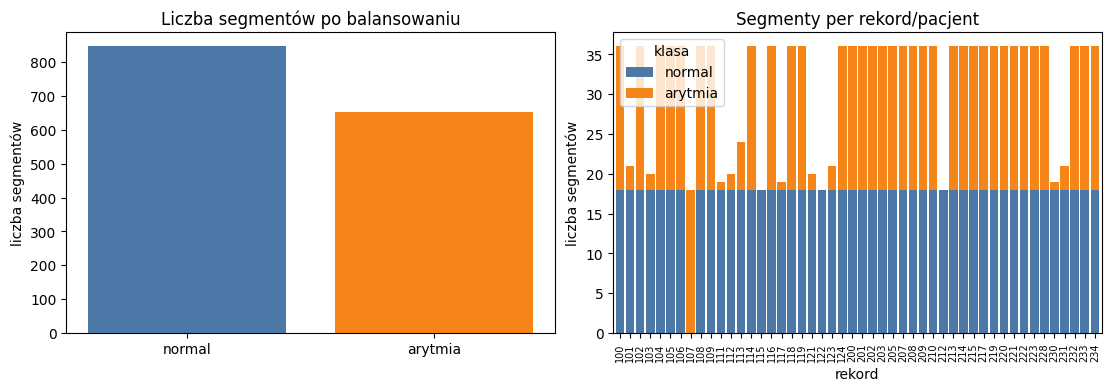

In [3]:
label_names = {0: "normal", 1: "arytmia"}
label_counts = segments["label"].map(label_names).value_counts().reindex(["normal", "arytmia"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].bar(label_counts.index, label_counts.values, color=["#4c78a8", "#f58518"])
axes[0].set_title("Liczba segmentów po balansowaniu")
axes[0].set_ylabel("liczba segmentów")

per_record = pd.crosstab(segments["record"], segments["label"]).rename(columns=label_names)
per_record.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c78a8", "#f58518"], width=0.85)
axes[1].set_title("Segmenty per rekord/pacjent")
axes[1].set_xlabel("rekord")
axes[1].set_ylabel("liczba segmentów")
axes[1].tick_params(axis="x", labelsize=7)
axes[1].legend(title="klasa")
plt.show()

## CWT jako obraz 2D

Dla każdej próbki liczona jest macierz `skale x czas`, następnie brana jest wartość bezwzględna
współczynników CWT, logarytmowana i standaryzowana. Obraz jest wejściem do sieci konwolucyjnej.

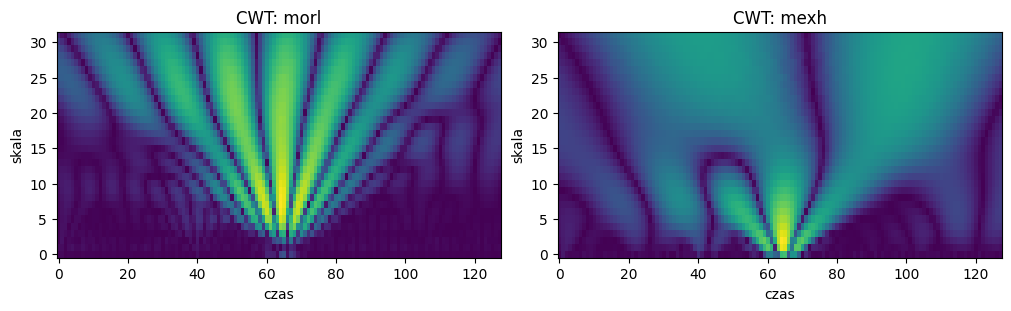

In [4]:
SCALES = np.arange(1, 33)
TARGET_TIME_POINTS = 128
WAVELETS = ["morl", "mexh"]


def cwt_image(segment: np.ndarray, wavelet: str) -> np.ndarray:
    segment = resample(segment, TARGET_TIME_POINTS)
    coef, _ = pywt.cwt(segment, SCALES, wavelet, sampling_period=1 / FS)
    image = np.log1p(np.abs(coef)).astype(np.float32)
    image = (image - image.mean()) / (image.std() + 1e-8)
    return image


def build_cwt_tensor(segments_df: pd.DataFrame, wavelet: str) -> np.ndarray:
    images = [cwt_image(seg, wavelet) for seg in segments_df["segment"].to_list()]
    return np.stack(images).astype(np.float32)


sample_segment = segments.iloc[0]["segment"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
for ax, wavelet in zip(axes, WAVELETS):
    ax.imshow(cwt_image(sample_segment, wavelet), aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"CWT: {wavelet}")
    ax.set_xlabel("czas")
    ax.set_ylabel("skala")
plt.show()

## Przykładowe sygnały przed i po CWT

Skala pojawia się dopiero po transformacie falkowej. Żeby porównanie miało te same osie, panel
„przed CWT” pokazuje znormalizowany segment EKG powielony wzdłuż osi skali, a panele „po CWT”
pokazują rzeczywiste obrazy `czas x skala` dla obu falek.

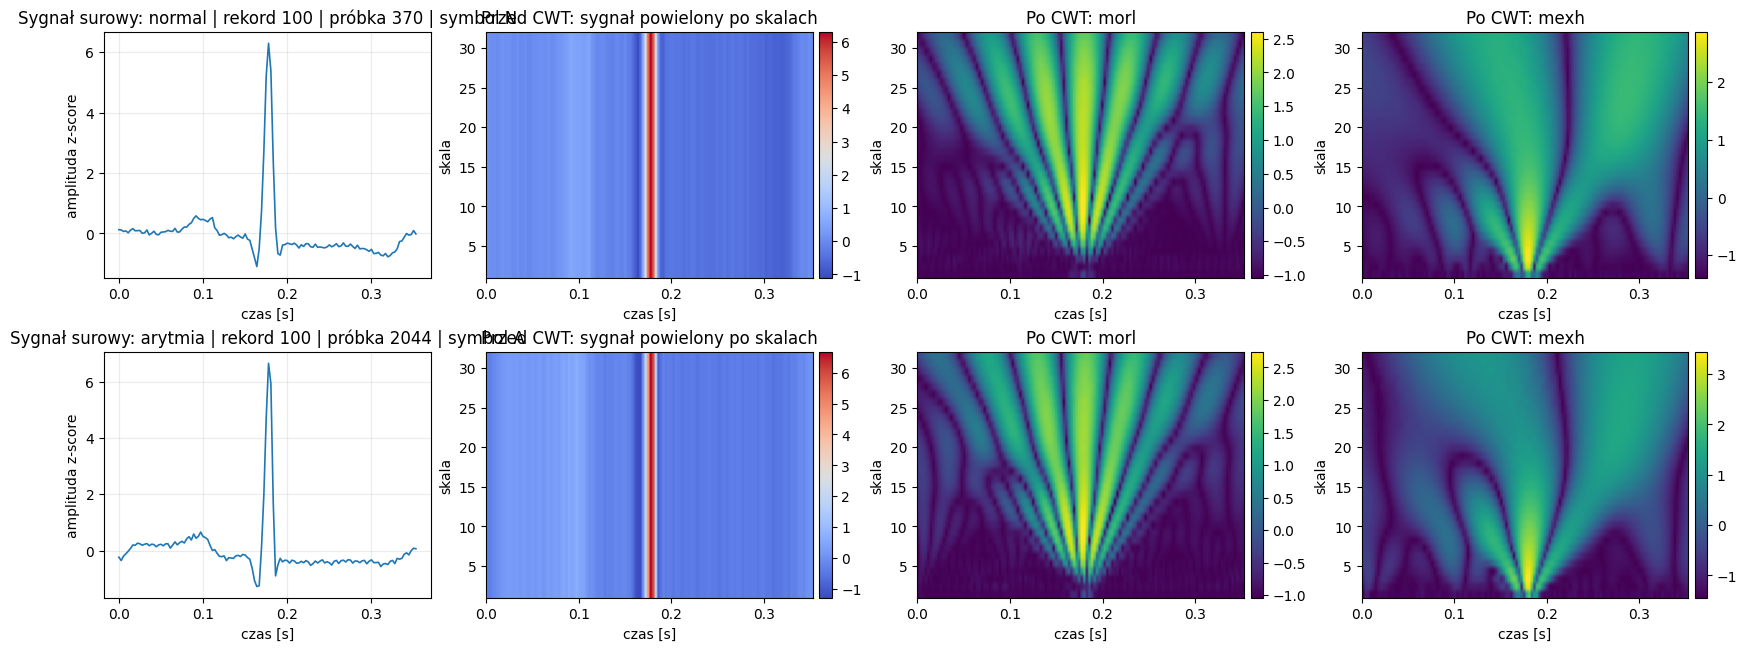

In [5]:
def raw_time_scale_map(segment: np.ndarray) -> np.ndarray:
    segment = resample(segment, TARGET_TIME_POINTS)
    segment = zscore(segment)
    return np.tile(segment, (len(SCALES), 1)).astype(np.float32)


def plot_cwt_before_after(example_rows: pd.DataFrame) -> None:
    time_axis = np.arange(TARGET_TIME_POINTS) / FS
    extent = [time_axis[0], time_axis[-1], SCALES[0], SCALES[-1]]
    n_rows = len(example_rows)
    n_cols = 2 + len(WAVELETS)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 3.2 * n_rows),
        constrained_layout=True,
    )
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (_, example) in enumerate(example_rows.iterrows()):
        segment = example["segment"]
        resampled = resample(segment, TARGET_TIME_POINTS)
        title = (
            f"{'normal' if example['label'] == 0 else 'arytmia'} "
            f"| rekord {example['record']} | próbka {example['sample']} | symbol {example['symbol']}"
        )

        axes[row_idx, 0].plot(time_axis, resampled, color="tab:blue", linewidth=1.2)
        axes[row_idx, 0].set_title(f"Sygnał surowy: {title}")
        axes[row_idx, 0].set_xlabel("czas [s]")
        axes[row_idx, 0].set_ylabel("amplituda z-score")
        axes[row_idx, 0].grid(alpha=0.25)

        raw_map = raw_time_scale_map(segment)
        im = axes[row_idx, 1].imshow(
            raw_map,
            aspect="auto",
            origin="lower",
            extent=extent,
            cmap="coolwarm",
        )
        axes[row_idx, 1].set_title("Przed CWT: sygnał powielony po skalach")
        axes[row_idx, 1].set_xlabel("czas [s]")
        axes[row_idx, 1].set_ylabel("skala")
        fig.colorbar(im, ax=axes[row_idx, 1], fraction=0.046, pad=0.02)

        for col_offset, wavelet in enumerate(WAVELETS, start=2):
            image = cwt_image(segment, wavelet)
            im = axes[row_idx, col_offset].imshow(
                image,
                aspect="auto",
                origin="lower",
                extent=extent,
                cmap="viridis",
            )
            axes[row_idx, col_offset].set_title(f"Po CWT: {wavelet}")
            axes[row_idx, col_offset].set_xlabel("czas [s]")
            axes[row_idx, col_offset].set_ylabel("skala")
            fig.colorbar(im, ax=axes[row_idx, col_offset], fraction=0.046, pad=0.02)

    plt.show()


example_segments = (
    segments.sort_values(["label", "record", "sample"])
    .groupby("label", group_keys=False)
    .head(1)
)
plot_cwt_before_after(example_segments)

## Średnie obrazy CWT dla klas

Poniżej widać uśrednione skalogramy dla klasy normalnej i arytmii. To szybka kontrola, czy obrazy CWT
faktycznie niosą informację rozróżniającą klasy przed uczeniem modelu.

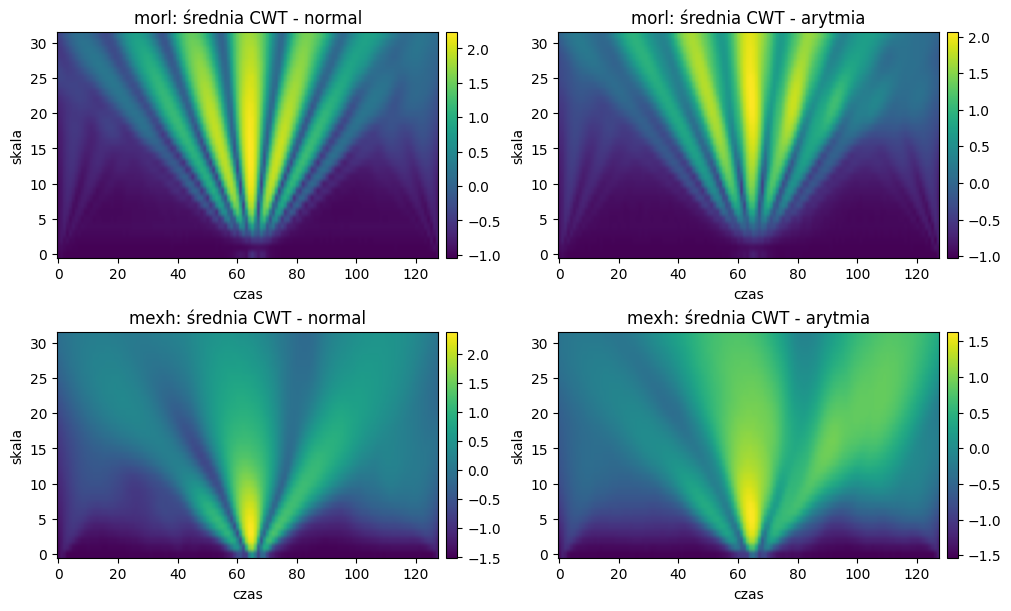

In [6]:
fig, axes = plt.subplots(len(WAVELETS), 2, figsize=(10, 6), constrained_layout=True)
for row_idx, wavelet in enumerate(WAVELETS):
    X_preview = build_cwt_tensor(segments, wavelet)
    for col_idx, label in enumerate([0, 1]):
        mean_image = X_preview[y == label].mean(axis=0)
        im = axes[row_idx, col_idx].imshow(mean_image, aspect="auto", origin="lower", cmap="viridis")
        axes[row_idx, col_idx].set_title(f"{wavelet}: średnia CWT - {label_names[label]}")
        axes[row_idx, col_idx].set_xlabel("czas")
        axes[row_idx, col_idx].set_ylabel("skala")
        fig.colorbar(im, ax=axes[row_idx, col_idx], fraction=0.046, pad=0.02)
plt.show()

## Mała sieć konwolucyjna

Klasyfikator jest lekką siecią konwolucyjną działającą bez PyTorcha/TensorFlow. Obraz CWT przechodzi przez
bank filtrów `Conv2D`, aktywację ReLU i pooling statystyczny. Na tak uzyskanych cechach uczona jest warstwa
klasyfikacyjna. To zachowuje konwolucyjne przetwarzanie obrazów CWT, a jednocześnie pozwala szybko
przeliczyć pełną walidację krzyżową w notebooku.

In [7]:
class SimpleCWTConvNet:
    def __init__(
        self,
        n_filters: int = 16,
        kernel_sizes: tuple[tuple[int, int], ...] = ((3, 7), (5, 11)),
        random_state: int = 42,
    ):
        self.n_filters = n_filters
        self.kernel_sizes = kernel_sizes
        self.random_state = random_state

    def _initialize_filters(self) -> None:
        rng = np.random.default_rng(self.random_state)
        self.filters_ = []
        for kh, kw in self.kernel_sizes:
            scale = np.sqrt(2 / (kh * kw))
            filters = rng.normal(0, scale, size=(self.n_filters, kh, kw)).astype(np.float32)
            self.filters_.append(filters)

    @staticmethod
    def _pool_feature_map(feature_map: np.ndarray) -> list[float]:
        relu = np.maximum(feature_map, 0)
        return [
            float(relu.mean()),
            float(relu.std()),
            float(relu.max()),
            float(np.percentile(relu, 75)),
        ]

    def transform(self, X: np.ndarray) -> np.ndarray:
        rows = []
        for image in X:
            features = []
            for filter_bank in self.filters_:
                for kernel in filter_bank:
                    feature_map = correlate2d(image, kernel, mode="same", boundary="fill")
                    features.extend(self._pool_feature_map(feature_map))
            rows.append(features)
        return np.array(rows, dtype=np.float32)

    def fit(self, X: np.ndarray, y: np.ndarray):
        self._initialize_filters()
        features = self.transform(X)
        self.classifier_ = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=600,
                class_weight="balanced",
                random_state=self.random_state,
            ),
        )
        self.classifier_.fit(features, y)
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.classifier_.predict_proba(self.transform(X))

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classifier_.predict(self.transform(X))

## Walidacja po pacjentach i metryki

Użyty jest `StratifiedGroupKFold`: stratyfikuje klasy, ale grupą jest rekord/pacjent. Dla każdego foldu
metryki są liczone na części testowej, a następnie uśredniane. MCC raportowane jest jako średnia z wartości
bezwzględnych.

In [8]:
y = segments["label"].to_numpy(dtype=np.int64)
groups = segments["record"].to_numpy()
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def normalize_by_train(X_img: np.ndarray, train_idx: np.ndarray, test_idx: np.ndarray):
    mean = X_img[train_idx].mean()
    std = X_img[train_idx].std() + 1e-8
    return (X_img[train_idx] - mean) / std, (X_img[test_idx] - mean) / std


def evaluate_wavelet(wavelet: str):
    print(f"Liczenie CWT dla falki: {wavelet}")
    X_img = build_cwt_tensor(segments, wavelet)
    fold_rows = []
    confusion_sum = np.zeros((2, 2), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_img, y, groups=groups), start=1):
        train_groups = set(groups[train_idx])
        test_groups = set(groups[test_idx])
        assert train_groups.isdisjoint(test_groups)

        X_train, X_test = normalize_by_train(X_img, train_idx, test_idx)
        clf = SimpleCWTConvNet(random_state=RANDOM_STATE + fold)
        clf.fit(X_train, y[train_idx])
        pred = clf.predict(X_test)

        row = {
            "wavelet": wavelet,
            "fold": fold,
            "train_records": len(train_groups),
            "test_records": len(test_groups),
            "test_samples": len(test_idx),
            "accuracy": accuracy_score(y[test_idx], pred),
            "precision_macro": precision_score(y[test_idx], pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y[test_idx], pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y[test_idx], pred, average="macro", zero_division=0),
            "mcc_abs": abs(matthews_corrcoef(y[test_idx], pred)),
        }
        fold_rows.append(row)
        confusion_sum += confusion_matrix(y[test_idx], pred, labels=[0, 1])
        print(
            f"fold {fold}: acc={row['accuracy']:.3f}, "
            f"f1={row['f1_macro']:.3f}, |MCC|={row['mcc_abs']:.3f}, "
            f"test records={sorted(test_groups)}"
        )

    return pd.DataFrame(fold_rows), confusion_sum


all_results = []
confusion_by_wavelet = {}
for wavelet in WAVELETS:
    fold_df, cm = evaluate_wavelet(wavelet)
    all_results.append(fold_df)
    confusion_by_wavelet[wavelet] = cm

results = pd.concat(all_results, ignore_index=True)
display(results)

Liczenie CWT dla falki: morl
fold 1: acc=0.629, f1=0.628, |MCC|=0.311, test records=['108', '111', '118', '203', '207', '212', '214', '223', '231', '233']
fold 2: acc=0.714, f1=0.699, |MCC|=0.405, test records=['100', '102', '106', '121', '122', '123', '124', '201', '220', '232']
fold 3: acc=0.726, f1=0.725, |MCC|=0.450, test records=['101', '105', '107', '114', '117', '200', '202', '208', '222', '228']
fold 4: acc=0.748, f1=0.748, |MCC|=0.546, test records=['103', '113', '115', '116', '119', '210', '217', '219', '221']
fold 5: acc=0.725, f1=0.722, |MCC|=0.443, test records=['104', '109', '112', '205', '209', '213', '215', '230', '234']
Liczenie CWT dla falki: mexh
fold 1: acc=0.674, f1=0.672, |MCC|=0.351, test records=['108', '111', '118', '203', '207', '212', '214', '223', '231', '233']
fold 2: acc=0.659, f1=0.634, |MCC|=0.284, test records=['100', '102', '106', '121', '122', '123', '124', '201', '220', '232']
fold 3: acc=0.816, f1=0.814, |MCC|=0.634, test records=['101', '105', '107

,wavelet,fold,train_records,test_records,test_samples,accuracy,precision_macro,recall_macro,f1_macro,mcc_abs
0,morl,1,38,10,310,0.629032,0.658319,0.652778,0.628379,0.311047
1,morl,2,38,10,311,0.713826,0.708072,0.696671,0.699458,0.404582
2,morl,3,38,10,310,0.725806,0.725241,0.725100,0.725163,0.450341
3,morl,4,39,9,278,0.748201,0.774634,0.771711,0.748149,0.546338
4,morl,5,39,9,291,0.725086,0.721504,0.721504,0.721504,0.443009
5,mexh,1,38,10,310,0.674194,0.673182,0.677778,0.671703,0.350929
6,mexh,2,38,10,311,0.659164,0.650395,0.633863,0.634361,0.283778
7,mexh,3,38,10,310,0.816129,0.821384,0.812980,0.814022,0.634308
8,mexh,4,39,9,278,0.830935,0.840616,0.847595,0.830670,0.688176
9,mexh,5,39,9,291,0.721649,0.720271,0.711312,0.713182,0.431490


In [9]:
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc_abs"]
summary = (
    results.groupby("wavelet")[metric_cols]
    .agg(["mean", "std"])
    .round(4)
)
display(summary)

ranking = results.groupby("wavelet")[metric_cols].mean().sort_values("f1_macro", ascending=False).round(4)
display(ranking)
print(f"Lepsza falka wg średniego F1 macro: {ranking.index[0]}")

accuracy         precision_macro         recall_macro          \
            mean     std            mean     std         mean     std   
wavelet                                                                 
mexh      0.7404  0.0795          0.7412  0.0861       0.7367  0.0906   
morl      0.7084  0.0461          0.7176  0.0416       0.7136  0.0435   

        f1_macro         mcc_abs          
            mean     std    mean     std  
wavelet                                   
mexh      0.7328  0.0866  0.4777  0.1765  
morl      0.7045  0.0459  0.4311  0.0850

,accuracy,precision_macro,recall_macro,f1_macro,mcc_abs
wavelet,,,,,
mexh,0.7404,0.7412,0.7367,0.7328,0.4777
morl,0.7084,0.7176,0.7136,0.7045,0.4311


Lepsza falka wg średniego F1 macro: mexh


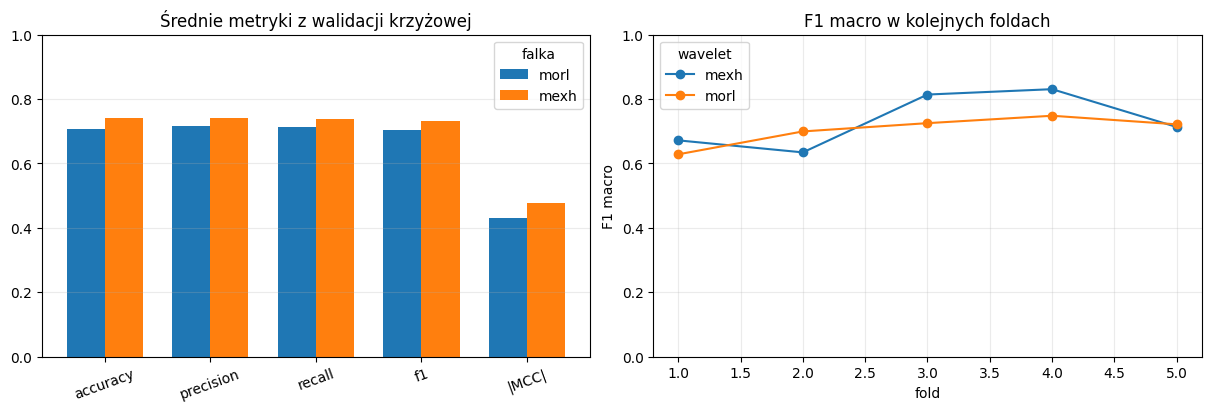

In [10]:
plot_summary = results.groupby("wavelet")[metric_cols].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

x = np.arange(len(metric_cols))
width = 0.36
for idx, wavelet in enumerate(WAVELETS):
    values = plot_summary.loc[plot_summary["wavelet"] == wavelet, metric_cols].iloc[0].to_numpy()
    axes[0].bar(x + (idx - 0.5) * width, values, width=width, label=wavelet)
axes[0].set_title("Średnie metryki z walidacji krzyżowej")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["accuracy", "precision", "recall", "f1", "|MCC|"], rotation=20)
axes[0].set_ylim(0, 1)
axes[0].legend(title="falka")
axes[0].grid(axis="y", alpha=0.25)

fold_metric = results.pivot(index="fold", columns="wavelet", values="f1_macro")
fold_metric.plot(ax=axes[1], marker="o")
axes[1].set_title("F1 macro w kolejnych foldach")
axes[1].set_xlabel("fold")
axes[1].set_ylabel("F1 macro")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
plt.show()

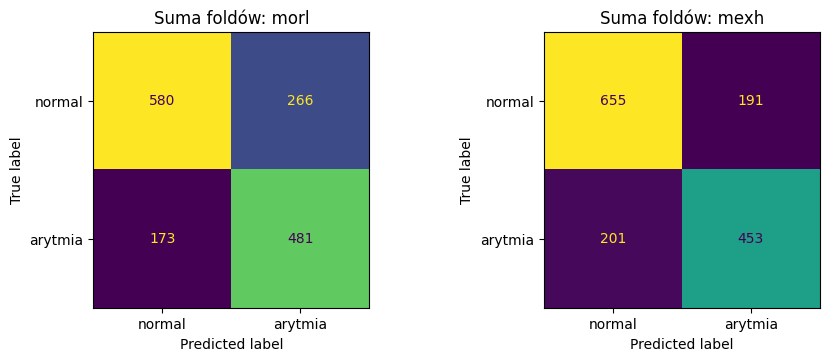

In [11]:
fig, axes = plt.subplots(1, len(WAVELETS), figsize=(9, 3.5), constrained_layout=True)
if len(WAVELETS) == 1:
    axes = [axes]
for ax, wavelet in zip(axes, WAVELETS):
    disp = ConfusionMatrixDisplay(confusion_by_wavelet[wavelet], display_labels=["normal", "arytmia"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Suma foldów: {wavelet}")
plt.show()

## Wnioski

Najlepsze wyniki w tej konfiguracji uzyskała falka `mexh`. Średnie wyniki z pięciofoldowej
walidacji `StratifiedGroupKFold` wyniosły:

| falka | accuracy | precision macro | recall macro | f1 macro | średnie \|MCC\| |
|---|---:|---:|---:|---:|---:|
| `mexh` | 0.7404 | 0.7412 | 0.7367 | 0.7328 | 0.4777 |
| `morl` | 0.7084 | 0.7176 | 0.7136 | 0.7045 | 0.4311 |

Najważniejsze elementy pipeline'u:

- dane: lokalne rekordy MIT-BIH, segmenty wokół adnotowanych pobudzeń,
- okno segmentu: 256 próbek, czyli około 0.71 s przy 360 Hz,
- kanał: `MLII`, a gdy go brakowało, pierwszy dostępny kanał EKG,
- etykiety: `0` dla pobudzeń normalnych AAMI (`N`, `L`, `R`, `e`, `j`) i `1` dla pozostałych pobudzeń jako arytmia,
- balansowanie: maksymalnie 18 segmentów z każdej klasy na rekord,
- CWT: skale `1..32`, obraz przeskalowany do 128 punktów w czasie,
- walidacja: `StratifiedGroupKFold(n_splits=5)`, z rekordem/pacjentem jako grupą,
- klasyfikator: lekka CNN `Conv2D -> ReLU -> pooling statystyczny -> warstwa logistyczna`.

Wyniki należy czytać razem z macierzami pomyłek, ponieważ accuracy samo w sobie może maskować pomyłki
między klasą normalną i arytmią. Średnie bezwzględne MCC jest tu dobrą metryką uzupełniającą: karze
jednocześnie fałszywe alarmy i pominięte arytmie, a dzięki wartości bezwzględnej odpowiada wymaganiu
z treści zadania.

Z punktu widzenia notatek najważniejsze jest to, że CWT zamienia krótki fragment EKG w obraz
czasowo-skalowy. Dzięki temu CNN może uczyć się lokalnych wzorców związanych z zespołem QRS i jego
zmianami, zamiast pracować wyłącznie na jednowymiarowym przebiegu. Różnice między falkami pokazują, że
wybór funkcji bazowej wpływa na to, które lokalne struktury sygnału są najmocniej podkreślone.